# <span style="color:rgb(213,80,0)">Tutorial 6 \- Simulate Thermal Performance</span>

## Introduction

In this tutorial, we will use a P4D model to simulate the thermal performance. We'll use the same model from Tutorial 1

## Setup material properties

In [1]:
jsonstruct_material = parseBattmoJson('Examples/jsondatafiles/sample_input.json');
jsonstruct_material.include_current_collectors = true;


## Setup the geometry

We use a 3D geometry where it is easier to visualize the thermal effects.


In [2]:
jsonstruct_geometry = parseBattmoJson('Examples/JsonDataFiles/geometry3d.json');
disp(jsonstruct_geometry)

    include_current_collectors: 1
                      Geometry: [1x1 struct]
             NegativeElectrode: [1x1 struct]
             PositiveElectrode: [1x1 struct]
                     Separator: [1x1 struct]
                  ThermalModel: [1x1 struct]


We merge the json structure. We get a warning for each field that gets different values from the given inputs. The rule is that the first input takes precedence, the warning can be switched off be setting the `'warn'` option to `false` in the call to `mergeStructs`.


In [3]:
jsonstruct = mergeStructs({jsonstruct_geometry , ...
    jsonstruct_material});

mergeStructs: Parameter Geometry.case is assigned twice with different values. Value from first jsonstruct is used.
mergeStructs: Parameter NegativeElectrode.Coating.thickness is assigned twice with different values 0.0001 and 6.4e-05, relative difference is 0.219512. Value from first jsonstruct is used.
mergeStructs: Parameter NegativeElectrode.Coating.N is assigned twice with different values 3 and 10, relative difference is 0.538462. Value from first jsonstruct is used.
mergeStructs: Parameter NegativeElectrode.CurrentCollector.N is assigned twice with different values 2 and 10, relative difference is 0.666667. Value from first jsonstruct is used.
mergeStructs: Parameter PositiveElectrode.Coating.thickness is assigned twice with different values 8e-05 and 5.7e-05, relative difference is 0.167883. Value from first jsonstruct is used.
mergeStructs: Parameter PositiveElectrode.Coating.N is assigned twice with different values 3 and 10, relative difference is 0.538462. Value from first 

In [4]:


jsonstruct.use_thermal = true;


We setup the model using the json structure.


In [5]:
model = setupModelFromJson(jsonstruct);


## Run the simulation

We run the simulation. We have used here a standard discharge control at C\-Rate=1.


In [6]:
output = runBattery(jsonstruct);


## Visualisation of the results

We plot the voltage versus time for the simulation.



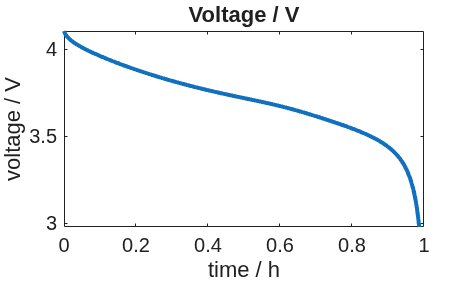

In [7]:
time = output.time;
E    = output.E;


set(0, 'defaulttextfontsize', 15);
set(0, 'defaultaxesfontsize', 15);
set(0, 'defaultlinelinewidth', 3);


figure
plot(time/hour, E)
title('Voltage / V');
xlabel('time / h');
ylabel('voltage / V');


We plot the minimum and maximum values of the temperature in the model as a function of time. The temperature for each grid cell, is stored in `state.ThermalModel.T`. For each computed step, we extract the minimum and maximum value of the temperature



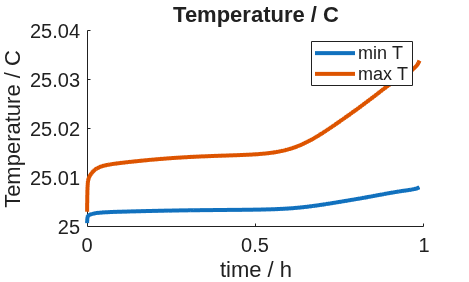

In [8]:
T0 = PhysicalConstants.absoluteTemperature;


states = output.states;
Tmin = cellfun(@(state) min(state.ThermalModel.T + T0), states);
Tmax = cellfun(@(state) max(state.ThermalModel.T + T0), states);


figure
hold on
plot(time / hour, Tmin, 'displayname', 'min T');
plot(time / hour, Tmax, 'displayname', 'max T');
title('Temperature / C')
xlabel('time / h');
ylabel('Temperature / C');


legend show


## Temperature distribution at final time

We have access to the temperature distribution for all the time steps. Here, we plot the temperature on the 3D model. We find a extensive set of plotting functions in [MRST](https://www.sintef.no/Projectweb/MRST/). You may be interested to have a look at the [Visualization Tutorial](https://www.sintef.no/projectweb/mrst/documentation/tutorials/visualization-tutorial/). We use [plotCellData](https://github.com/SINTEF-AppliedCompSci/MRST/blob/main/core/plotting/plotCellData.m) to plot the temperature. The function [plotToolbar.m](https://github.com/SINTEF-AppliedCompSci/MRST/blob/main/visualization/mrst-gui/plotToolbar.m) is also convenient to visualize values inside the domain in a interactive way.


In [9]:
state = states{end}

state = struct with fields:
    NegativeElectrode: [1x1 struct]
    PositiveElectrode: [1x1 struct]
          Electrolyte: [1x1 struct]
         ThermalModel: [1x1 struct]
              Control: [1x1 struct]
                 time: 3.5517e+03


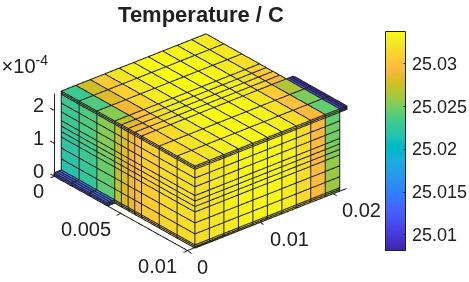

In [10]:
figure
plotCellData(model.ThermalModel.grid, ...
    state.ThermalModel.T + T0);
colorbar
title('Temperature / C');
view([50, 50]);


## The external heat transfer coefficient

The external heat transfer coefficient and the external temperature have a strong influence on the value of the temperature inside the model. The value of the external temperature has been given in the json input and passed to the model.


In [11]:
disp(model.ThermalModel.externalTemperature);

  298.1500


The values of the heat transfer coefficient have been processed from the json structure. For this 3D geometry, the external heat transfer coefficient is given by a value that is used at the tab


In [12]:
disp(jsonstruct.ThermalModel.externalHeatTransferCoefficientTab);

        1000


and an other that is used for the remaining external faces,


In [13]:
disp(jsonstruct.ThermalModel.externalHeatTransferCoefficient);

   100


From those values, when the model is setup, a value is assigned to all the external faces of the model. This value is stored in `model.ThermalModel.externalHeatTransferCoefficient`. Let us plot its value the 3D model. In the coupling term of the thermal model (coupling to the exterior model), we get the list of the face indices that are coupled thermally, which are in fact allthe external faces.


In [14]:
extfaceind = model.ThermalModel.couplingTerm.couplingfaces;
G          = model.ThermalModel.grid;
nf         = G.faces.num;


We create a vector with one value per face and we set this value equal to the external heat transfer coefficient for the corresponding external face.



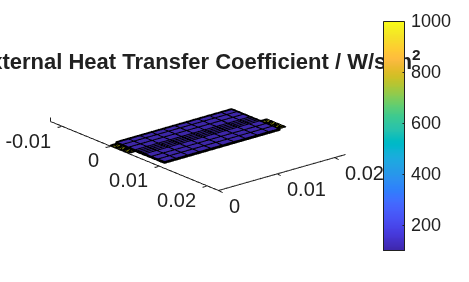

In [15]:
val = NaN(nf, 1);
val(extfaceind) = model.ThermalModel.externalHeatTransferCoefficient;


figure
plotFaceData(G, val, 'edgecolor', 'black');
axis equal
view([50, 20]);
title('External Heat Transfer Coefficient / W/s/m^2')
colorbar


Let us modify the heat transfer coefficients and rerun the simulation to observe the effects.


In [16]:
jsonstruct.ThermalModel.externalHeatTransferCoefficientTab = 100;
jsonstruct.ThermalModel.externalHeatTransferCoefficient = 0;


We run the model for the new values


In [17]:
output = runBattery(jsonstruct);


We plot the results



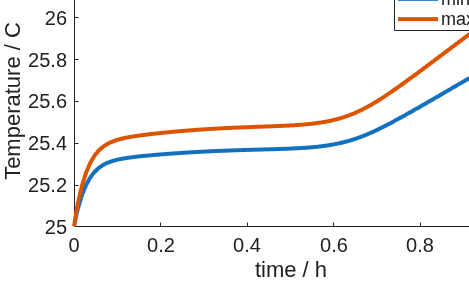

In [18]:
states = output.states;


Tmin = cellfun(@(state) min(state.ThermalModel.T + T0), states);
Tmax = cellfun(@(state) max(state.ThermalModel.T + T0), states);
time = output.time;


figure
hold on
plot(time / hour, Tmin, 'displayname', 'min T');
plot(time / hour, Tmax, 'displayname', 'max T');
title('Temperature / C')
xlabel('time / h');
ylabel('Temperature / C');


legend show